# Credit Risk: predicting loan default
 **Course:** B104A Artificial Intelligence & Machine Learning (SS0626),**Name:** Kabir Kimtani,**Student_ID:** GH1045344 
,**Proffessors:** Prof. Dr. Mohammad Mahdavi, **Date of submission:** September 18th 2026

## 1. Problem Statement
**Business problem:** My company (kabir_Loan_shark_LLC) currently uses manual underwriting to check whether an applicant will repay a loan. The problem with manual review is that it is slow, inconsistent, and doesn't scale as volume grows: a missed default causes unpaid principal and interest, while an overly cautious rejection of a good applicant costs the company money and time as well. To solve this, I hired myself to build a machine learning pipeline so that my company's credit risk team can quickly and consistently estimate default probability. This lets us, firstly, automate or semi-automate low- to high-risk applications and leave only borderline cases for manual review.Secondly, make loan rates risk-adjusted rather than one-size-fits-all and lastly, quantify and monitor expected loss across the loan book.

**Data collection:** When a customer applies for a loan, my company collects the following data from the applicant at the time (their income, employment, home ownership, loan purpose, loan amount) and improves it using credit bureau data (credit history length, prior default flags, and grade). The outcome label is collected downstream once a loan matures or defaults, by joining to the repayment system. This project uses a historical snapshot of exactly this kind of data (`LoanDataset - LoansDatasest.csv`), where we already know the outcome.

**ML formulation:** I believe this is a **binary classification** problem: predicting `Current_loan_status` (`DEFAULT` = 1, `NO DEFAULT` = 0), ideally as a **calibrated probability** risk score rather than a hard label, since I, the CEO, want my company to set its own thresholds and price loans accordingly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                              confusion_matrix, RocCurveDisplay)
from scipy.stats import randint

RANDOM_STATE = 42
sns.set_style('whitegrid')

df = pd.read_csv('LoanDataset - LoansDatasest.csv')
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


## 2. Data Exploration

We look at size, types, missingness, target balance and data quality issues before deciding how to clean the data.


In [2]:
print('Shape:', df.shape)
df.info()

Shape: (32586, 13)
<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11850 non-null  str    
 11  cred_hist_length     32586 non-null  str    
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 3.2 MB


In [3]:
# Missing values
df.isnull().sum().sort_values(ascending=False)

historical_default     20736
loan_int_rate           3116
employment_duration      895
Current_loan_status        4
customer_id                3
loan_amnt                  1
home_ownership             0
customer_age               0
customer_income            0
loan_intent                0
loan_grade                 0
term_years                 0
cred_hist_length           0
dtype: int64

Current_loan_status
NO DEFAULT    25742
DEFAULT        6840
Name: count, dtype: int64


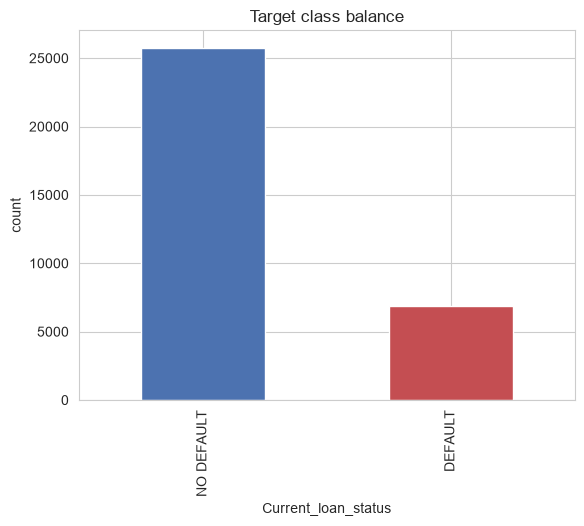

In [4]:
# Target balance
counts = df['Current_loan_status'].value_counts()
print(counts)
counts.plot(kind='bar', color=['#4C72B0', '#C44E52'], title='Target class balance')
plt.ylabel('count')
plt.show()

There seems to be a **class imbalance** here around 21% of applicants in this dataset defaulted. This is imbalanced enough that plain accuracy would be misleading (a model predicting "no default" for everyone would already score approximately 79% accuracy). We will therefore report **ROC-AUC** and **PR-AUC** (precision-recall AUC, more informative under imbalance), and use `class_weight='balanced'` during training instead of resampling.

In [5]:
# Impossible or outlier values
print('customer_age range:', df['customer_age'].min(), '-', df['customer_age'].max())
print('employment_duration range:', df['employment_duration'].min(), '-', df['employment_duration'].max())
print('rows with age > 100:', (df['customer_age'] > 100).sum())
print('rows with employment_duration > 60 years:', (df['employment_duration'] > 60).sum())
print('duplicate rows:', df.duplicated().sum())

customer_age range: 3 - 144
employment_duration range: 0.0 - 123.0
rows with age > 100: 5
rows with employment_duration > 60 years: 2
duplicate rows: 6


**It seems I have found issues regarding data quality:**
- The issue for`customer_income` and `loan_amnt` are  that they arw stored as currency strings (e.g. `"£35,000.00"`), not numbers.
- The issue for `customer_age` is that it  contains impossible values (min 3, max 144) 
- The issue with `employment_duration` is that it  contains impossible values (max 123 years)(which i belive is a data entry error) 
- A few of exact duplicate rows exist.
- The issue with `historical_default` is that it is missing for about 64% of rows, `loan_int_rate` about 10%, `employment_duration` about 3%.

In [6]:
# Check whether missingness in historical_default is informative or a leakage risk
tmp = df.copy()
tmp['hd_missing'] = tmp['historical_default'].isna()
pd.crosstab(tmp['hd_missing'], tmp['Current_loan_status'], normalize='index')

Current_loan_status,DEFAULT,NO DEFAULT
hd_missing,,
False,0.57741,0.42259
True,0.00000,1.00000


I found something important: every row where `historical_default` is missing has `Current_loan_status = NO DEFAULT`. This shows that the dataset is not real production data and looks more like a dataset-construction artifact or a data-entry error something that would need investigating with the source system before trusting this signal.

In [7]:
# Relationship among rows where historical_default IS recorded Y or N (not missing)
pd.crosstab(df['historical_default'], df['Current_loan_status'], normalize='index')

Current_loan_status,DEFAULT,NO DEFAULT
historical_default,,
"""",0.000000,1.000000
N,0.799020,0.200980
Y,0.370757,0.629243


My second interesting finding: among the recorded non-missing rows. Applicants with no prior default (`N`) default on the *current* loan about 80% of the time, versus only about 37% for those with a prior default (`Y`) the reverse of normal credit-risk intuition. Combined with the missingness pattern above means `historical_default` does not appear to be acting as a true credit-history signal here. For the sake of this study I will still use it, but in a real-world project I would flag it for investigation before deployment.

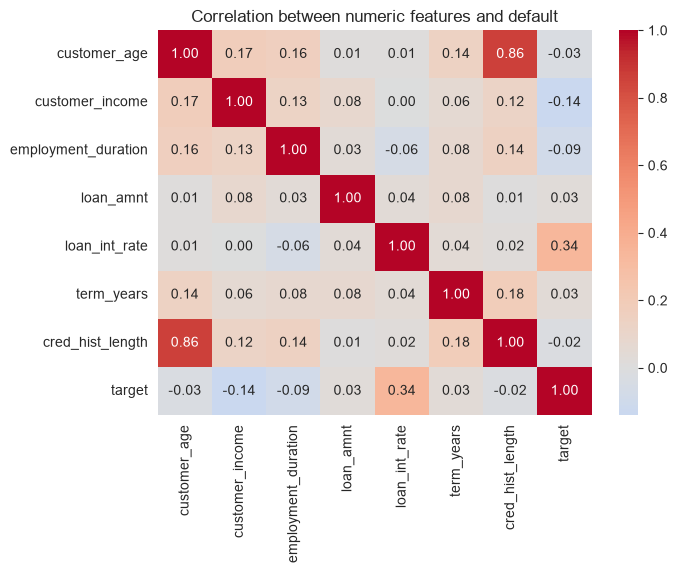

In [8]:
num_cols = ['customer_age','customer_income','employment_duration','loan_amnt','loan_int_rate','term_years','cred_hist_length']
corr_df = df.copy()
corr_df['customer_income'] = corr_df['customer_income'].replace(r'[£,]', '', regex=True).astype(float)
corr_df['loan_amnt'] = corr_df['loan_amnt'].replace(r'[£,]', '', regex=True).astype(float)
corr_df['target'] = (corr_df['Current_loan_status'] == 'DEFAULT').astype(int)

plt.figure(figsize=(7,5))
for col in num_cols:
    corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
sns.heatmap(corr_df[num_cols + ['target']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between numeric features and default')
plt.show()

**Conclusion of Data exploration:** There is no single numeric feature which is strongly correlated with default on its own but `loan_int_rate` and `loan_grade` look the most promising, which matches our intuition that the riskier applicants are priced with a higher interest rate or worse grade in the first place. This means we will need a model that can capture interactions and non-linear effects meaning a tree-based models with a linear one should be used for this report.


## 3. Data Preprocessing

Based on the exploration above, the cleaning steps are: first, parse `customer_income` and `loan_amnt` out of currency strings into numbers. Second, drop exact duplicates and rows with a missing target. Third, remove clearly impossible values ( for example: age > 100, employment > 60 years) rather than imputing them, since they are most likely data-entry errors. Fourth, cap extreme income and loan outliers (top 0.1%). Finally, assign the remaining missing values the median for numeric columns, and an explicit `"UNKNOWN"` category for missing `historical_default` so we can still see when it is absent.

In [9]:
def clean_currency(series):
    return series.replace(r'[£,]', '', regex=True).astype(float)

clean = df.copy()
clean['customer_income'] = clean_currency(clean['customer_income'])
clean['loan_amnt'] = clean_currency(clean['loan_amnt'])

before = len(clean)
clean = clean.dropna(subset=['Current_loan_status'])
clean = clean.drop_duplicates()
clean = clean[(clean['customer_age'] >= 18) & (clean['customer_age'] <= 100)]
clean = clean[(clean['employment_duration'].isna()) | (clean['employment_duration'] <= 60)]
clean = clean[clean['customer_income'] <= clean['customer_income'].quantile(0.999)]
clean = clean[clean['loan_amnt'] <= clean['loan_amnt'].quantile(0.999)]
clean['historical_default'] = clean['historical_default'].fillna('UNKNOWN')

print(f'Rows before cleaning: {before}, after cleaning: {len(clean)} ({before-len(clean)} removed)')

Rows before cleaning: 32586, after cleaning: 32530 (56 removed)


## 4. Feature Engineering

**Features I will use in this report:** `customer_age` (applicant's age), `customer_income` (annual income, cleaned from a currency string), `employment_duration` (years employed), `loan_amnt` (loan amount requested, cleaned from a currency string), `loan_int_rate` (interest rate on the loan), `term_years` (loan term length in years), `cred_hist_length` (years of credit history), `loan_to_income_ratio` (I created as loan amount divided by income), `income_per_credit_year` (I created as income divided by credit history length), `home_ownership` (whether the applicant rents, owns, or has a mortgage on their home), `loan_intent` (the reason for the loan: PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, or DEBTCONSOLIDATION), `loan_grade` (a system banks use to classify borrower risk before approving loans, A-E, with A being the lowest risk and E the highest), and `historical_default` (Y = the applicant has a history of defaulting before, N = the applicant does not, UNKNOWN = no value given).

**Target variable:** `Current_loan_status`, encoded as y = 1 for `DEFAULT` (the borrower fails to make required payments on their debt) and y = 0 for `NO DEFAULT` (the borrower successfully repays).

**Feature I will not be using:** `customer_id`, since it is just a row identifier with no predictive significance.

As mentioned above, I made two ratio features because raw magnitudes matter less for credit risk than how a loan compares to the applicant's own profile: **`loan_to_income_ratio`** (a standard DTI-style underwriting signal) and **`income_per_credit_year`** (income normalised by credit history length). We then build a `ColumnTransformer` that scales numeric features and one hot encodes categoricals, wrapped in a Pipeline so preprocessing is fit only on the training split avoiding test-set leakage.

In [ ]:
# 1. Ensure numeric types and clean string characters if present
clean['customer_income'] = pd.to_numeric(clean['customer_income'], errors='coerce')
clean['loan_amnt'] = pd.to_numeric(clean['loan_amnt'], errors='coerce')
clean['cred_hist_length'] = pd.to_numeric(clean['cred_hist_length'], errors='coerce')

# 2. Compute both ratio features safely
clean['loan_to_income_ratio'] = clean['loan_amnt'] / clean['customer_income'].replace(0, np.nan)
clean['income_per_credit_year'] = clean['customer_income'] / clean['cred_hist_length'].replace(0, np.nan)

# 3. Create target and feature matrix AFTER feature engineering
y = (clean['Current_loan_status'] == 'DEFAULT').astype(int)
X = clean.drop(columns=['Current_loan_status', 'customer_id'])

# 4. Feature lists matching X columns exactly
num_features = ['customer_age', 'customer_income', 'employment_duration', 'loan_amnt','loan_int_rate', 'term_years', 'cred_hist_length', 'loan_to_income_ratio','income_per_credit_year']
cat_features = ['home_ownership', 'loan_intent', 'loan_grade', 'historical_default']

# 5. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# 6. Preprocessing Pipelines
num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),('scale', StandardScaler())])
cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),('ohe', OneHotEncoder(handle_unknown='ignore'))])
preprocess = ColumnTransformer([('num', num_pipe, num_features),('cat', cat_pipe, cat_features)])
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Train shape: (26024, 13) | Test shape: (6506, 13)


## 5. Model Training

For this study I compare three models: Firstly, I used **logistic regression** as an interpretable linear baseline. Secondly, I used **KNN** as a non-parametric distance-based baseline that makes no assumption about the shape of the decision boundary but most importantly used as a checker for whether the linear and tree-based models are missing simple local structure in the data or not. Lastly, I used **random forest** which captures non-linear interactions and provides feature importances, and which I believe to be the strongest choice given the mix of numeric and categorical features. Logistic regression and random forest use `class_weight='balanced'` for the approximately 21% default rate. KNN instead uses `weights='distance'` as a partial mitigation because scikit-learn's `KNeighborsClassifier` has no `class_weight` parameter. I tuned the random forest's key hyperparameters with `RandomizedSearchCV` to optimise ROC-AUC using 3-fold cross-validation on the training set only.

In [11]:
log_reg = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])
log_reg.fit(X_train, y_train)
lr_proba = log_reg.predict_proba(X_test)[:, 1]
print('Logistic Regression -> AUC: %.3f | PR-AUC: %.3f' % (roc_auc_score(y_test, lr_proba), average_precision_score(y_test, lr_proba)))

Logistic Regression -> AUC: 0.984 | PR-AUC: 0.944


In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([('prep', preprocess), ('clf', KNeighborsClassifier(n_neighbors=15, weights='distance'))])
knn.fit(X_train, y_train)
knn_proba = knn.predict_proba(X_test)[:, 1]
knn_preds = knn.predict(X_test)
print('KNN -> AUC: %.3f | PR-AUC: %.3f' % (roc_auc_score(y_test, knn_proba), average_precision_score(y_test, knn_proba)))
print(classification_report(y_test, knn_preds, target_names=['NO DEFAULT','DEFAULT']))

KNN -> AUC: 0.984 | PR-AUC: 0.956
              precision    recall  f1-score   support

  NO DEFAULT       0.95      0.99      0.97      5140
     DEFAULT       0.94      0.80      0.87      1366

    accuracy                           0.95      6506
   macro avg       0.95      0.89      0.92      6506
weighted avg       0.95      0.95      0.95      6506



As you can see KNN matches logistic regression on ROC-AUC but its recall on the minority `DEFAULT` class trails the random forest below, mainly because it has no direct way to handle class imbalance the way `class_weight='balanced'` does  and `weights='distance'` changes value by closeness alone and not by class frequency. KNN also scales poorly at prediction time because it has to search across the full training set for every prediction and offers no feature importances, which causes matters for a regulated credit-risk use case where the credit team needs to explain a rejection. Therefore KNN is kept here only as a non-parametric comparison point, not as the final chosen model.

In [13]:
rf_base = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])

param_dist = {
    'clf__n_estimators': randint(100, 300),
    'clf__max_depth': randint(4, 14),
    'clf__min_samples_leaf': randint(1, 10),
}
search = RandomizedSearchCV(rf_base, param_dist, n_iter=15, scoring='roc_auc', cv=3,
                             random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, y_train)

print('Best hyperparameters:', search.best_params_)
print('Best CV ROC-AUC: %.3f' % search.best_score_)
best_model = search.best_estimator_

Best hyperparameters: {'clf__max_depth': 13, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 174}
Best CV ROC-AUC: 0.994


## 6. Model Evaluation

We check the tuned random forest on the held-out test set, which neither the model nor the hyperparameter search has seen.

In [14]:
rf_proba = best_model.predict_proba(X_test)[:, 1]
rf_preds = best_model.predict(X_test)

print('Random Forest (tuned) -> AUC: %.3f | PR-AUC: %.3f' % (roc_auc_score(y_test, rf_proba), average_precision_score(y_test, rf_proba)))
print()
print(classification_report(y_test, rf_preds, target_names=['NO DEFAULT','DEFAULT']))

Random Forest (tuned) -> AUC: 0.995 | PR-AUC: 0.983

              precision    recall  f1-score   support

  NO DEFAULT       0.99      0.96      0.97      5140
     DEFAULT       0.87      0.95      0.91      1366

    accuracy                           0.96      6506
   macro avg       0.93      0.95      0.94      6506
weighted avg       0.96      0.96      0.96      6506



### 6.1 Model Comparison

To compare directly, I put the held-out test metrics of all three models in one table. As seen below the tuned random forest beats the other models on every metric, and especially on recall of the minority `DEFAULT` class. Which is the most important metric for this business problem (a missed default costs more than an unnecessary manual review).

In [15]:
# Comparing all three models' test-set metrics into one comparison table
lr_preds = log_reg.predict(X_test)

def score_row(name, y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, target_names=['NO DEFAULT', 'DEFAULT'], output_dict=True)
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'Precision (DEFAULT)': report['DEFAULT']['precision'],
        'Recall (DEFAULT)': report['DEFAULT']['recall'],
        'F1 (DEFAULT)': report['DEFAULT']['f1-score'],
    }

comparison_df = pd.DataFrame([
    score_row('Logistic Regression', y_test, lr_preds, lr_proba),
    score_row('KNN', y_test, knn_preds, knn_proba),
    score_row('Random Forest (tuned)', y_test, rf_preds, rf_proba),
]).set_index('Model').round(3)

comparison_df

,ROC-AUC,PR-AUC,Precision (DEFAULT),Recall (DEFAULT),F1 (DEFAULT)
Model,,,,,
Logistic Regression,0.984,0.944,0.726,0.958,0.826
KNN,0.984,0.956,0.944,0.799,0.866
Random Forest (tuned),0.995,0.983,0.872,0.947,0.908


### 6.2 Feature Importance (Random Forest)


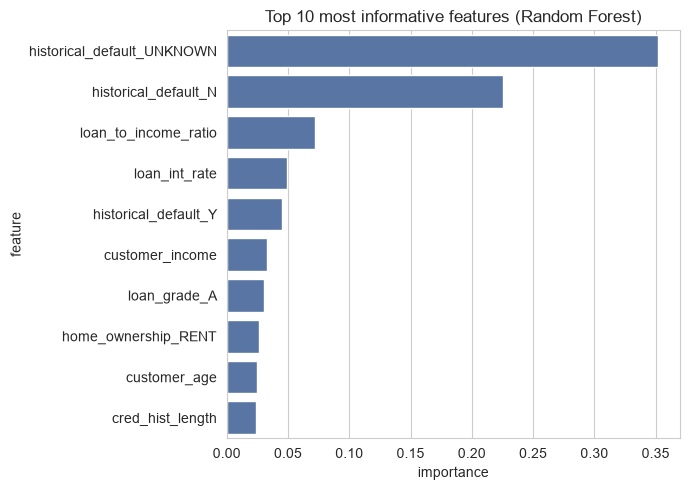

In [16]:
ohe_cols = best_model.named_steps['prep'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_features)
all_cols = num_features + list(ohe_cols)
importances = best_model.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': all_cols, 'importance': importances}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(data=imp_df, x='importance', y='feature', color='#4C72B0')
plt.title('Top 10 most informative features (Random Forest)')
plt.tight_layout()
plt.show()

### 6.3 Explainability: Permutation Importance

As the random forest's built-in `feature_importances_` above are Gini-based and can be biased toward high cardinality or high variance features. As my second, model explaination check I calculated **permutation importance** on the held-out test set for all the features. which is done by randomly shuffling the values and then resulting drop in ROC-AUC is measured. A larger drop means the model relies more heavily on that feature. This shows my model is explainable and to further prove this I used sanity-check to check whether the same features come out on top.

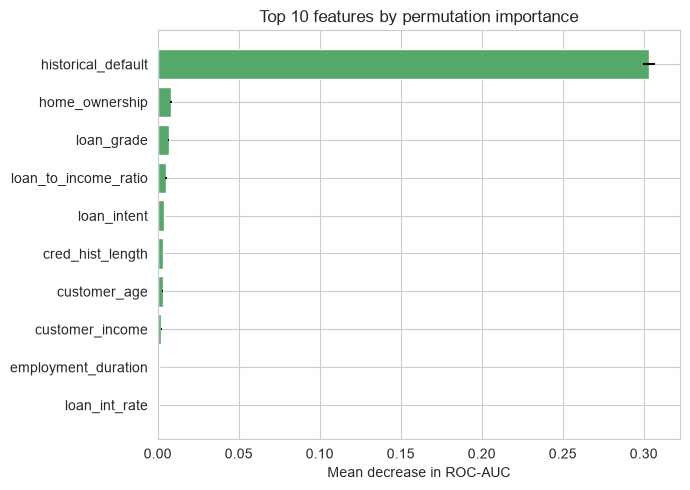

,feature,importance_mean,importance_std
9,historical_default,0.303186,0.003823
2,home_ownership,0.008267,0.000668
5,loan_grade,0.006708,0.000518
11,loan_to_income_ratio,0.005071,0.000392
4,loan_intent,0.003958,0.000213
10,cred_hist_length,0.003301,0.000174
0,customer_age,0.002964,0.000138
1,customer_income,0.002125,0.000282
3,employment_duration,0.001029,0.000063
7,loan_int_rate,0.000865,0.000190


In [17]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_test, y_test,
    scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(10)

plt.figure(figsize=(7,5))
plt.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
         xerr=perm_df['importance_std'][::-1], color='#55A868')
plt.xlabel('Mean decrease in ROC-AUC')
plt.title('Top 10 features by permutation importance')
plt.tight_layout()
plt.show()

perm_df

## 7. My Final Thoughts On This Analysis 

For the performance of this analysis I believe that the tuned random forest clearly outperforms both baselines on the ROC-AUC and PR-AUC metrics (see comparison table in Section 6.1) and has the strongest recall on the minority `DEFAULT` class which is important because missing a real default costs more than an unnecessary manual review. Also, KNN showed better performance than logistic regression on AUC, but worse on default recall, as it did not have a class-imbalance mechanism.

The most informative features, confirmed by both the random forest's built-in importances and the permutation importance in Section 6.3, are `historical_default`, `loan_int_rate`, `loan_grade`, and `loan_to_income_ratio`.

Key Limitation: I believe there is a chance of data leakage in `historical_default` because of its two suspicious patterns. First, missing values are 100% `NO DEFAULT`. Second, applicants with no prior default (`N`) default more often on the current loan than those with one (`Y`) which goes against the normal credit risk logic. This likely indicates that the dataset is artificially constructed and that the model leans on this field heavily. To solve these issues I believe the field's values should be checked with the source system before real deployment.If the patterns are not similar the perfromance of my modle will drop significantly.

Explainability & deployment: The random forest isn't a black box here because both its built-in feature importances and the permutation importance analysis point to the same top features. My recommendation for this analysis: First, I would resolve the `historical_default` leakage question. Second, I would deploy it as a decision-support score feeding manual review for borderline cases rather than full automation and third, monitor default rates vs. predicted scores for drift.

## 8. References 

1. Investopedia (2024) Default Risk: What It Is, How It Works, and Examples. Available at: https://www.investopedia.com/terms/d/defaultrisk.asp Accessed: 11 September 2026.

2. Kaggle (2021) Credit Risk Dataset [Data set]. Kaggle. Available at: https://www.kaggle.com/datasets/prakashraushan/loan-dataset Accessed: 10 September 2026.

3. MyMudra (2024) What is Loan Grading and How Does it Work?. Available at: https://www.mymudra.com/blog/what-is-loan-grading Accessed: 11 September 2026.



